[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/syaikhipin/kdd26-memdiag/blob/tutorial-rebuild/tutorial/phase3_autoresearch/02_run_your_group.ipynb)

> **Run this notebook in Google Colab** — click the badge above. The setup cell auto-clones the repo.


# Phase 3B - Run your group's slice (Modal L4)

**Phase 3B - Run YOUR group's slice on Modal L4 (~14.5 min).** Independent notebook - runs standalone in Colab or locally.

## 0. Setup (self-contained)

Runs anywhere — **Google Colab** (a Colab GPU is optional) or **modal.com**. The heavy
autoresearch sweep always trains on a **Modal L4 GPU**
(`scripts/build_autoresearch_trace.py`), so you don't need a local/Colab GPU.

**Google Colab** — the setup cell installs `modal`. Authenticate with a **token**, not
`!modal setup` (its browser flow redirects to `localhost`, which Colab can't reach, so the
URL is "not found"). Create a token at **modal.com → Settings → API tokens** (Token ID
`ak-…` + Token Secret `as-…`), then run in a cell:

```python
!modal token set --token-id ak-........ --token-secret as-........
!modal token current        # verify: prints your workspace + token id
```

To avoid re-pasting after a Colab runtime restart, store the token as a Colab secret
(`MODAL_TOKEN_ID`, `MODAL_TOKEN_SECRET`) and inject it:

```python
from google.colab import userdata
!modal token set --token-id {userdata.get('MODAL_TOKEN_ID')} --token-secret {userdata.get('MODAL_TOKEN_SECRET')}
```

A Colab GPU runtime is fine but not required — the training runs on Modal.

**modal.com** — `modal` is already installed and authenticated; just run the cells below.


In [ ]:
# Self-contained setup - works standalone in Google Colab or locally.
import sys, os, subprocess
from pathlib import Path
REPO_URL = "https://github.com/syaikhipin/kdd26-memdiag"
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False
if IN_COLAB:
    repo = Path("/content/kdd26-memdiag")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", "tutorial-rebuild", REPO_URL, str(repo)], check=False)
    SOURCE = repo / "source"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "matplotlib", "pyyaml", "openai", "modal"], check=False)
else:
    SOURCE = None
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for sub in ("source", "experiment"):
            if (cand / sub / "run.py").exists():
                SOURCE = cand / sub
                break
        if SOURCE:
            break
    if SOURCE is None:
        raise FileNotFoundError("Run from the repo root (or in Colab it auto-clones).")
sys.path.insert(0, str(SOURCE))
SOURCE_DIR = SOURCE
PROJECT_ROOT = SOURCE.parent
RESULTS_DIR = PROJECT_ROOT / "results"
try: _d = "<repo>/" + str(Path(SOURCE).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d, "| found =", True, "| IN_COLAB =", IN_COLAB)

try: _d = "<repo>/" + str(Path(SOURCE_DIR).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d)

## ⚙️ Set up your LLM at the beginning — base URL · API key · model
On first run this cell **prompts you for three things**: your OpenAI-compatible **base URL**, **API key** (hidden input), and **model**. They are saved to **Google Drive** in Colab (or `config/kdd26_memdiag_config.json` locally) so every other notebook and every future session reuses them — you set up **once**. Press **Enter** to keep a default / run offline. To reconfigure later: set `KDD_RECONFIG=1` or delete that file. Template: `config/kdd26_memdiag_config_sample.json`.

In [ ]:
# === Set up your LLM at the beginning: base URL · API key · model ===
# Prompts ONCE (saved to Google Drive in Colab, or config/kdd26_memdiag_config.json locally) -> reused by EVERY notebook & session.
# To re-prompt later: set os.environ['KDD_RECONFIG']='1', or delete the saved config file.
from config import setup_llm                       # shared helper in source/config.py
OPENAI_BASE_URL, OPENAI_API_KEY, OPENAI_MODEL = setup_llm()
from llm_client import LLMConfig, make_client
try:
    llm = make_client(LLMConfig(backend="openai-compatible" if OPENAI_API_KEY else "offline",
                                base_url=OPENAI_BASE_URL, model=OPENAI_MODEL))
    print("llm      =", llm.backend)
except Exception:
    llm = None
    print("llm      = (env vars set for CLI tools)")


Set GROUP to your assigned letter, then run:

In [ ]:
GROUP = 'A' # A | B | C | D
import subprocess
from pathlib import Path

def _mask(s):
    """Mask local absolute paths so nothing machine-specific leaks into the output."""
    s = str(s)
    try: s = s.replace(str(PROJECT_ROOT), "<repo>")
    except NameError: pass
    return s.replace(str(Path.home()), "~")

script = str(PROJECT_ROOT / 'scripts' / 'build_autoresearch_trace.py')
_r = subprocess.run(['modal','run', script, '--group', GROUP], cwd=str(PROJECT_ROOT), capture_output=True, text=True)
if _r.returncode:
    print(f"modal run (group {GROUP}) exited {_r.returncode} - the real error is below.")
    print("(Common causes: Modal token not set for this session, the L4 image build / data-prep step")
    print(" failed, or the autoresearch/ code dir is missing from the repo. You can also skip this")
    print(f" cell - leaderboard/{GROUP}.json may already exist if your group already ran.)")
    if _r.stderr.strip():
        print("--- modal stderr (tail) ---")
        print(_mask(_r.stderr[-2500:]))
    if _r.stdout.strip():
        print("--- modal stdout (tail) ---")
        print(_mask(_r.stdout[-1500:]))
else:
    print(_mask(_r.stdout[-1500:]))
    print('group', GROUP, 'done -> <repo>/source/data/topics/autoresearch/leaderboard/'+GROUP+'.json')

### 📊 Visualize — why we split into groups (depth vs batch)

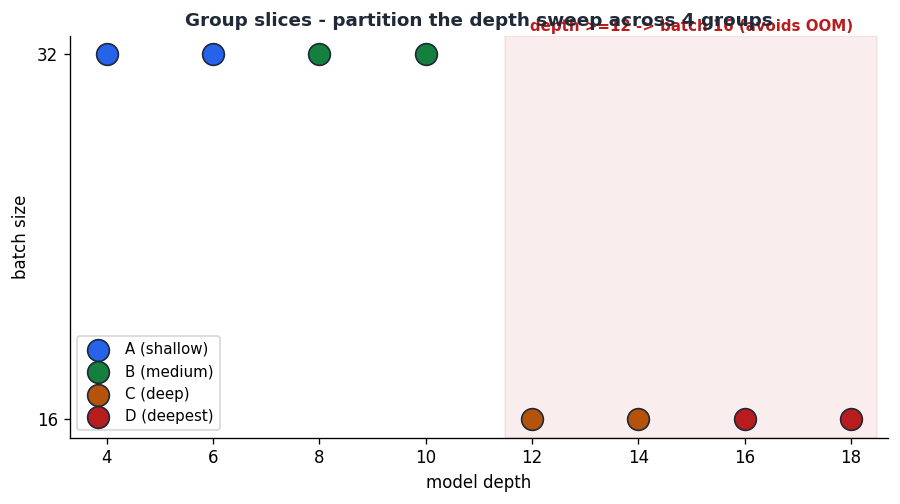

In [4]:
import matplotlib.pyplot as plt
groups={"A (shallow)":[(4,32),(6,32)],"B (medium)":[(8,32),(10,32)],"C (deep)":[(12,16),(14,16)],"D (deepest)":[(16,16),(18,16)]}
cols=["#2563EB","#15803D","#B45309","#B91C1C"]
fig,ax=plt.subplots(figsize=(7.6,4.3),dpi=120)
for (g,configs),c in zip(groups.items(),cols):
    ax.scatter([d for d,b in configs],[b for d,b in configs],s=170,color=c,label=g,zorder=3,edgecolor="#1F2937")
ax.axvspan(11.5,18.5,alpha=0.08,color="#B91C1C")
ax.text(15,33,"depth >=12 -> batch 16 (avoids OOM)",color="#B91C1C",fontsize=9,ha="center",weight="bold")
ax.set_xlabel("model depth"); ax.set_ylabel("batch size")
ax.set_title("Group slices - partition the depth sweep across 4 groups",color="#1F2937",weight="bold",fontsize=11)
ax.set_xticks([4,6,8,10,12,14,16,18]); ax.set_yticks([16,32])
ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False); fig.tight_layout(); plt.show()